In [13]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

from py_files import GallenModel_v1, metrics, train
import importlib
importlib.reload(GallenModel_v1)
importlib.reload(metrics)
importlib.reload(train)
import tensorflow as tf
from tensorflow.keras.models import load_model
from py_files.data import dataframe_to_dataset, preprocessing
import geopandas as gpd
from matplotlib import pyplot as plt
import seaborn as sns
import contextily as cx
import numpy as np
import matplotlib.colors as mcolors
from py_files.data import NormalizationLayer
from py_files.metrics import plot_distribution, plot_susceptibility_map, plot_landslide_distribution
from py_files.GallenModel_v1 import  NewmarkActivation, DisplacementLayer, LandslideActivationLayer, CohesionLayer, InternalFrictionLayer, ClipLayer

# HOW TO RUN MODEL
* Load model
* Prepare Dataset
* Preprocess data



In [14]:
model = load_model("/Users/giogonzales/Documents/ml-prep/ML-PREP-2025/learn/trainedWeights/trainedCotabatoPhase7/historical/v4-2-2-fos/fold-1-model-0.keras", custom_objects={
    "tf":tf,
    "ClipLayer":ClipLayer
}, safe_mode=False)

In [15]:
df = gpd.read_file('~/Documents/ml-prep/ML-PREP-2025/learn/data/SU_15_Validation1.gpkg')

In [16]:
df, columns, numeric_cols = preprocessing(df, ['landslide_probability', 'landslide_preds', 'confusion', 'sus_pinn_landslide', 'sus_pinn_ground truth', 'ds', 'cohesion', 'internal_friction'])
df, columns, numeric_cols

(            DN     BD_mean   Clay_mean   Sand_mean   Silt_mean  NDVI_mean  \
 0       260790   92.500000  391.000000  297.000000  311.500000   0.736663   
 1       258113   92.242665  391.176284  298.942952  310.150950   0.752155   
 2       260623   92.000000  393.437924  294.584463  312.247812   0.773809   
 3       259982   92.000000  394.000000  297.000000  309.000000   0.783758   
 4       258881   92.933318  383.133364  293.333410  323.599907   0.791762   
 ...        ...         ...         ...         ...         ...        ...   
 241057  359271  122.000000  363.373509  334.599835  301.785990   0.567125   
 241058  359194  123.693475  354.818482  335.441132  310.232286   0.793491   
 241059  359382  120.000000  367.000000  342.000000  291.000000   0.656603   
 241060  359306  122.000000  356.449362  329.739234  314.101276   0.624058   
 241061  359150  122.000000  355.000000  328.000000  317.000000   0.599981   
 
         Est_mean  Nrt_mean  HorCurv_mean  VertCurv_mean  ... 

In [17]:
dataset = dataframe_to_dataset(df[columns], shuffle=False)
susceptibility_prediction = model.predict(dataset)

7534/7534 ━━━━━━━━━━━━━━━━━━━━ 4s 508us/step


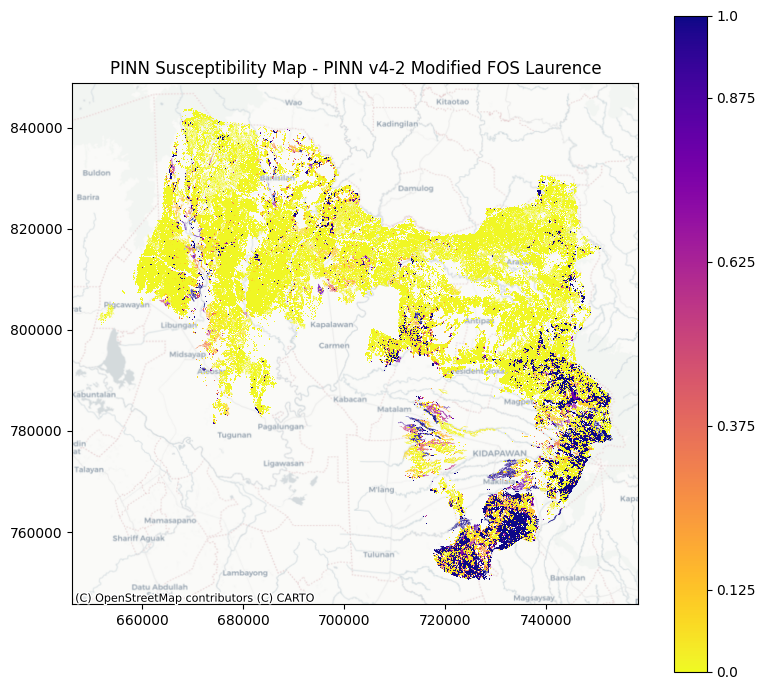

In [18]:
plot_susceptibility_map(df, susceptibility_prediction, "PINN v4-2 Modified FOS Laurence")

# PLOT Factor of Safety 


7534/7534 ━━━━━━━━━━━━━━━━━━━━ 4s 533us/step


Text(0.5, 1.0, 'Newmark Displacement')

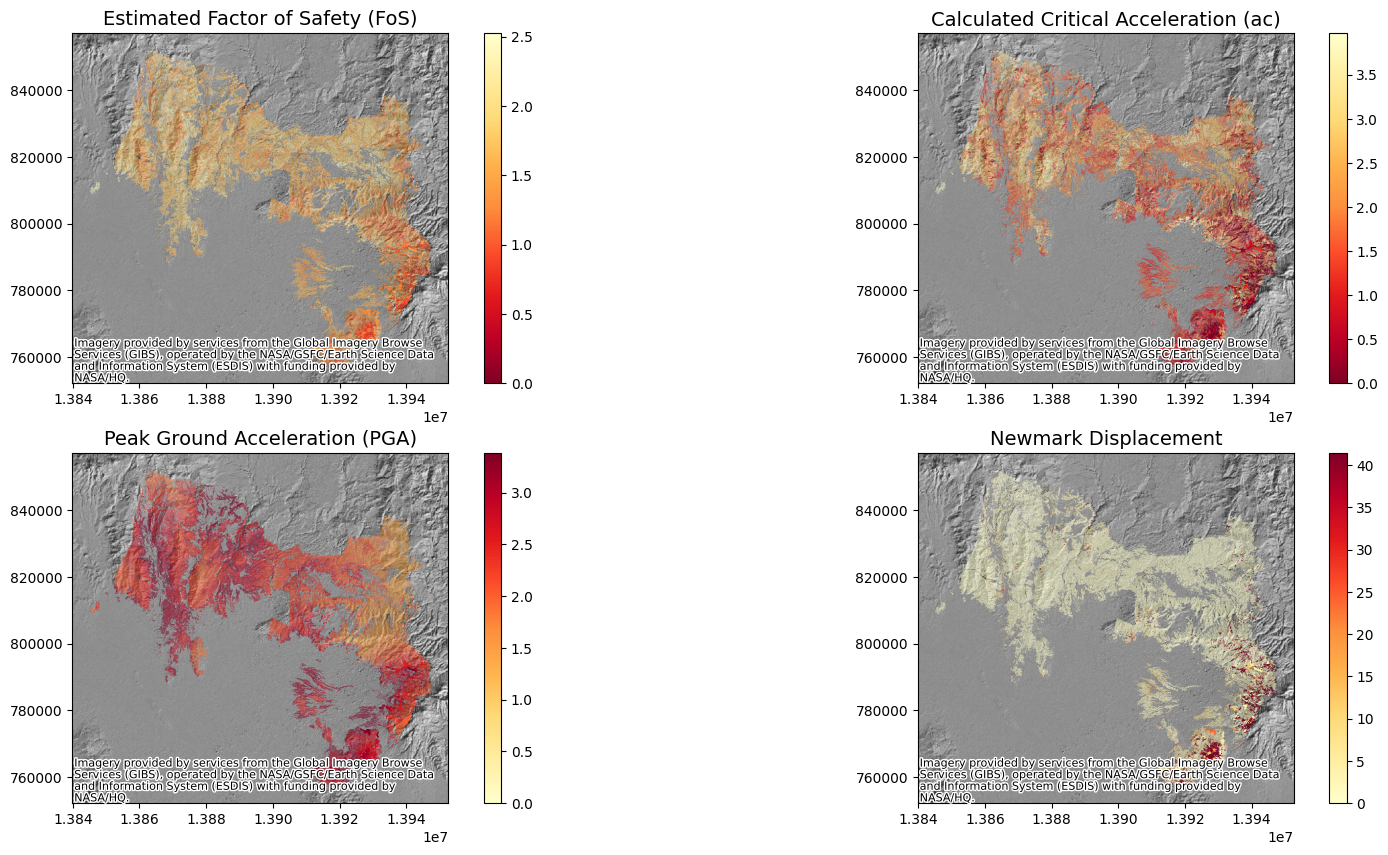

In [20]:
df_wm = df.to_crs(epsg=3857)
fos_model = tf.keras.Model(inputs=model.inputs, outputs=model.get_layer("fos_layer").output)
predicted_fos = fos_model.predict(dataset)
df_wm['estimated_fos'] = predicted_fos


#Retrieve and create FOS model and plot result
fig, ax = plt.subplots(2, 2, figsize=(20, 10))
norm = mcolors.Normalize(vmin=0, vmax=df_wm['estimated_fos'].quantile(0.95))
df_wm.plot(column="estimated_fos", legend=True, alpha=0.7, norm=norm, ax=ax[0][0], cmap='YlOrRd_r')
cx.add_basemap(ax=ax[0][0],source='NASAGIBS.ASTER_GDEM_Greyscale_Shaded_Relief')


#Convert slope to radians and calculated the critical acceleration based on the equation
df_wm['slope_radians'] = df_wm['Slope_mean'] * 0.017453292519943295
df_wm['calculated_ac'] = (df_wm['estimated_fos'] - 1) * 9.81 * np.sin(df_wm['slope_radians'])


#Plot calculated critical acceleration
ac_norm = mcolors.Normalize(vmin=0, vmax=df_wm['calculated_ac'].quantile(0.95))
df_wm.plot(column="calculated_ac", legend=True, alpha=0.7, norm=ac_norm, ax=ax[0][1], cmap='YlOrRd_r')
cx.add_basemap(ax=ax[0][1],source='NASAGIBS.ASTER_GDEM_Greyscale_Shaded_Relief')

#Convert PGA from g to cm/s^2
df_wm['PGA_cm'] = df_wm['PGA1_max'] * 9.81

#Plot PGA map
ac_norm = mcolors.Normalize(vmin=0, vmax=df_wm['PGA_cm'].quantile(0.95))
df_wm.plot(column="PGA_cm", legend=True, alpha=0.7, norm=ac_norm, ax=ax[1][0], cmap="YlOrRd")
cx.add_basemap(ax=ax[1][0],source='NASAGIBS.ASTER_GDEM_Greyscale_Shaded_Relief')

df_wm['estimated_susceptibility'] = susceptibility_prediction

df_wm['PGA1_max'] *= 9.81

df_wm['acpg'] = df_wm['calculated_ac'] / df_wm['PGA1_max']
df_wm['acpg'] = np.clip(df_wm['acpg'], 0.001, 0.75)
powcomp = np.pow((1 - df_wm['acpg']), 2.341) * np.pow(df_wm['acpg'], -1.438)
logds = 0.215 + np.log(powcomp) + 0.51  # NOTE:: Newmark Displacement

df_wm['calculated_ds'] = np.exp(logds)

#Plot calculated displacement using Newmark Displacement method
ac_norm = mcolors.Normalize(vmin=0, vmax=df_wm['calculated_ds'].quantile(0.95))
df_wm.plot(column='calculated_ds', legend=True, alpha=0.7, ax=ax[1][1], cmap="YlOrRd", norm=ac_norm)
cx.add_basemap(ax=ax[1][1],source='NASAGIBS.ASTER_GDEM_Greyscale_Shaded_Relief')

ax[0][0].set_title("Estimated Factor of Safety (FoS)", fontsize=14)
ax[0][1].set_title("Calculated Critical Acceleration (ac)", fontsize=14)
ax[1][0].set_title("Peak Ground Acceleration (PGA)", fontsize=14)
ax[1][1].set_title("Newmark Displacement", fontsize=14)
